In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from skimage.metrics import structural_similarity as ssim
import math

In [5]:
def read_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def show_image(img, title=""):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def save_image(name, img):
    cv2.imwrite(name, img)

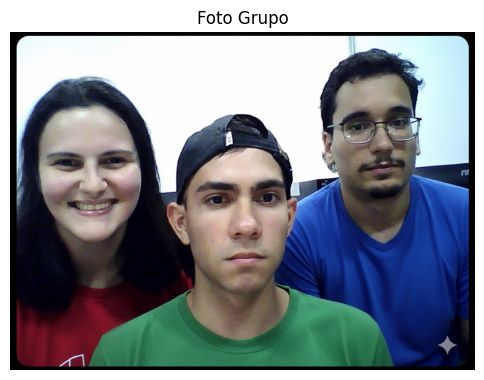

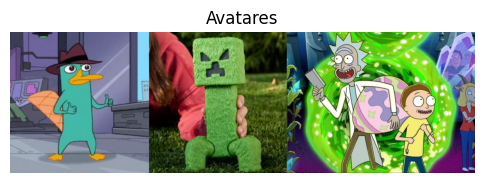

In [6]:
foto_grupo = read_image("static/foto-grupo.jpg")
avatar = read_image("static/avatares.jpg")

show_image(foto_grupo, "Foto Grupo")
show_image(avatar, "Avatares")

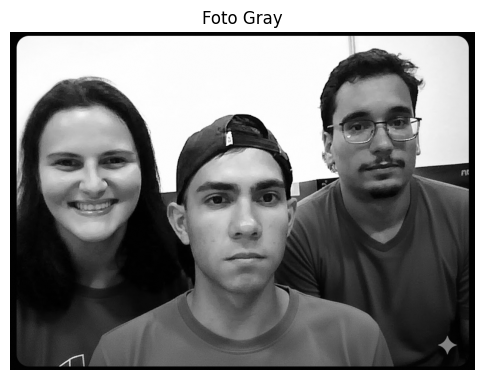

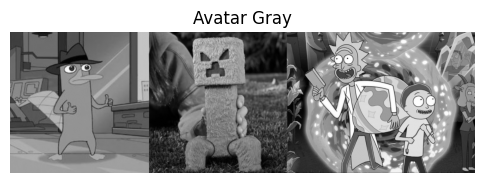

In [7]:
foto_gray = cv2.cvtColor(foto_grupo, cv2.COLOR_RGB2GRAY)
avatar_gray = cv2.cvtColor(avatar, cv2.COLOR_RGB2GRAY)

show_image(foto_gray, "Foto Gray")
show_image(avatar_gray, "Avatar Gray")

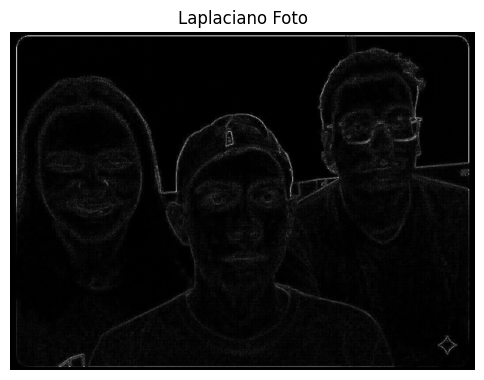

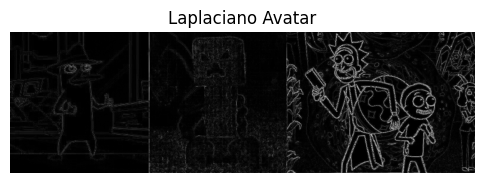

In [8]:
lap_foto = cv2.Laplacian(foto_gray, cv2.CV_64F)
lap_avatar = cv2.Laplacian(avatar_gray, cv2.CV_64F)

lap_foto = np.uint8(np.absolute(lap_foto))
lap_avatar = np.uint8(np.absolute(lap_avatar))

save_image("laplaciano_foto.jpg", lap_foto)
save_image("laplaciano_avatar.jpg", lap_avatar)

show_image(lap_foto, "Laplaciano Foto")
show_image(lap_avatar, "Laplaciano Avatar")

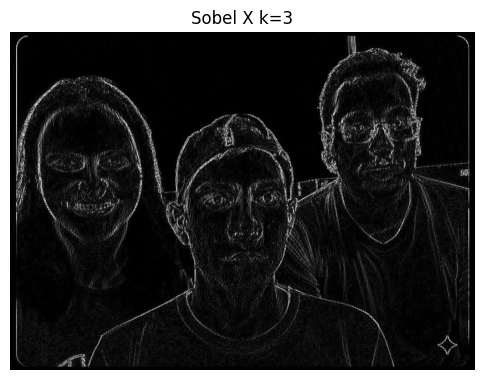

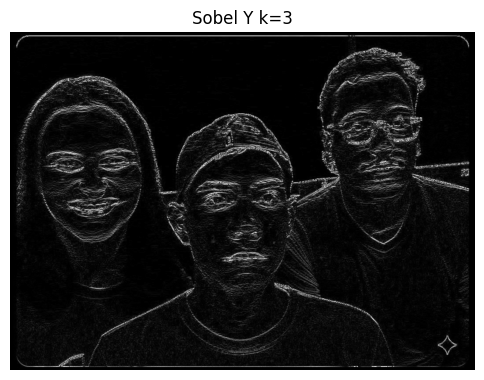

In [9]:
sobelx_foto_k3 = cv2.Sobel(foto_gray, cv2.CV_64F, 1, 0, ksize=3)
sobely_foto_k3 = cv2.Sobel(foto_gray, cv2.CV_64F, 0, 1, ksize=3)

sobelx_foto_k3 = np.uint8(np.absolute(sobelx_foto_k3))
sobely_foto_k3 = np.uint8(np.absolute(sobely_foto_k3))

save_image("sobelx_foto_k3.jpg", sobelx_foto_k3)
save_image("sobely_foto_k3.jpg", sobely_foto_k3)

show_image(sobelx_foto_k3, "Sobel X k=3")
show_image(sobely_foto_k3, "Sobel Y k=3")

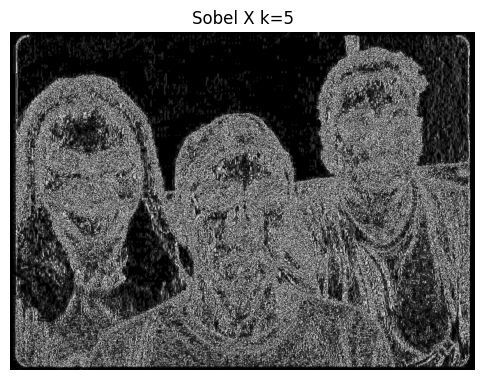

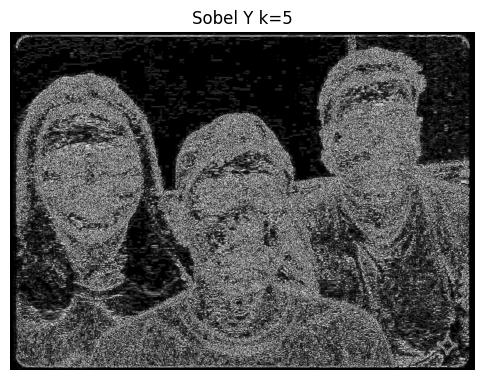

In [10]:
sobelx_foto_k5 = cv2.Sobel(foto_gray, cv2.CV_64F, 1, 0, ksize=5)
sobely_foto_k5 = cv2.Sobel(foto_gray, cv2.CV_64F, 0, 1, ksize=5)

sobelx_foto_k5 = np.uint8(np.absolute(sobelx_foto_k5))
sobely_foto_k5 = np.uint8(np.absolute(sobely_foto_k5))

save_image("sobelx_foto_k5.jpg", sobelx_foto_k5)
save_image("sobely_foto_k5.jpg", sobely_foto_k5)

show_image(sobelx_foto_k5, "Sobel X k=5")
show_image(sobely_foto_k5, "Sobel Y k=5")

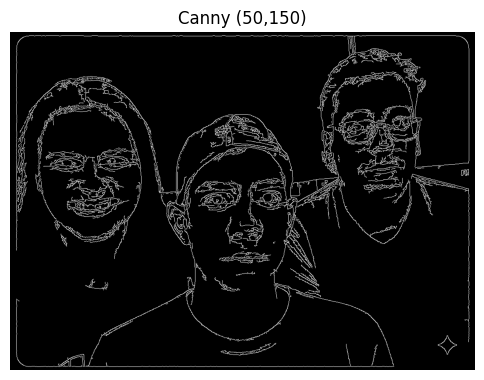

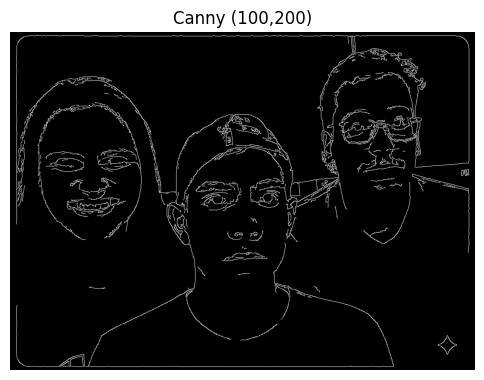

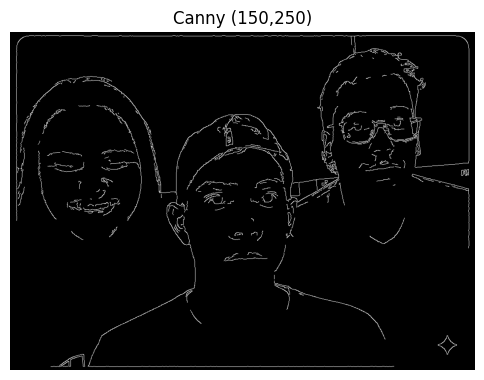

In [11]:
canny1 = cv2.Canny(foto_gray, 50, 150)
canny2 = cv2.Canny(foto_gray, 100, 200)
canny3 = cv2.Canny(foto_gray, 150, 250)

save_image("canny_1.jpg", canny1)
save_image("canny_2.jpg", canny2)
save_image("canny_3.jpg", canny3)

show_image(canny1, "Canny (50,150)")
show_image(canny2, "Canny (100,200)")
show_image(canny3, "Canny (150,250)")

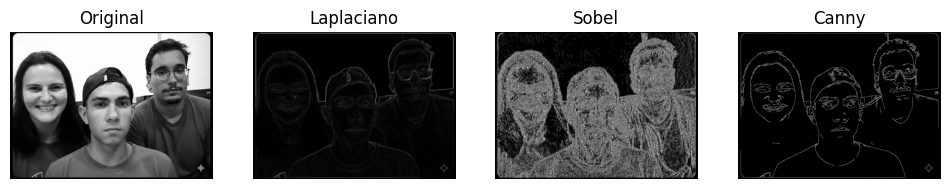

In [12]:
plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(foto_gray, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(lap_foto, cmap='gray')
plt.title("Laplaciano")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(sobelx_foto_k5, cmap='gray')
plt.title("Sobel")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(canny2, cmap='gray')
plt.title("Canny")
plt.axis("off")

plt.show()

Ao observar a ultima celula é possivel analisar como os filtros de passa-alta destacam as bordas das imagens de maneiras diferentes utilizando-se das mais diversas logicas matematicas, filtro Laplaciano detecta bordas em todas as direções, porém mostra maior sensibilidade a ruídos. Os filtros Sobel X e Sobel Y destacam bordas horizontais e verticais, sendo possível observar que o aumento do kernel torna as bordas mais suaves. Já o filtro Canny apresentou os melhores resultados visuais, pois gera bordas mais finas e remove boa parte do ruído, resultando em uma representação mais clara dos contornos das imagens

Ranking dos filtros utilizados:

#1 Canny
#2 Sobel X
#3 Sobel Y
#4 Laplaciano